In [1]:
print("Eduvanta Academy Learning Analytics — notebook connected successfully.")

Eduvanta Academy Learning Analytics — notebook connected successfully.


# Eduvanta Academy Learning & Student Success Analytics

## Data Exploration & Quality Assessment

**Project:** Eduvanta Academy Learning & Student Success Analytics  
**Dataset:** Synthetic educational data  
**Learners:** 100 K–8 learners  
**Period:** September 2025 – August 2026  

### Purpose

This notebook explores learner performance, engagement, progress, assessment outcomes, and parent/guardian support patterns.

The analysis is designed to answer practical educational analytics questions while demonstrating professional data analysis skills using Python and Pandas.

### Responsible Analytics

This dataset is synthetic and does not represent real students.

The analysis is intended to identify educational patterns and support evidence-based decision-making. It is not intended to diagnose learners or make unsupported judgments about individual students.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

learners = pd.read_csv(RAW_DATA_DIR / "learners.csv")
courses = pd.read_csv(RAW_DATA_DIR / "courses.csv")
learning_activity = pd.read_csv(
    RAW_DATA_DIR / "learning_activity.csv"
)
assessments = pd.read_csv(
    RAW_DATA_DIR / "assessments.csv"
)
progress = pd.read_csv(
    RAW_DATA_DIR / "progress.csv"
)
parent_support = pd.read_csv(
    RAW_DATA_DIR / "parent_support.csv"
)

print("All six Eduvanta Academy datasets loaded successfully.")

All six Eduvanta Academy datasets loaded successfully.


In [3]:
table_summary = pd.DataFrame({
    "Table": [
        "learners",
        "courses",
        "learning_activity",
        "assessments",
        "progress",
        "parent_support"
    ],
    "Rows": [
        len(learners),
        len(courses),
        len(learning_activity),
        len(assessments),
        len(progress),
        len(parent_support)
    ],
    "Columns": [
        learners.shape[1],
        courses.shape[1],
        learning_activity.shape[1],
        assessments.shape[1],
        progress.shape[1],
        parent_support.shape[1]
    ]
})

table_summary

,Table,Rows,Columns
0,learners,100,4
1,courses,12,6
2,learning_activity,5594,9
3,assessments,2245,10
4,progress,1200,11
5,parent_support,154,10


In [4]:
datasets = {
    "learners": learners,
    "courses": courses,
    "learning_activity": learning_activity,
    "assessments": assessments,
    "progress": progress,
    "parent_support": parent_support
}

for name, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(name.upper())
    print(f"{'=' * 60}")
    print("Columns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes)


LEARNERS
Columns:
['learner_id', 'grade_level', 'enrollment_date', 'learning_level']

Data types:
learner_id         str
grade_level        str
enrollment_date    str
learning_level     str
dtype: object

COURSES
Columns:
['course_id', 'course_name', 'subject', 'grade_level', 'topic', 'lesson_count']

Data types:
course_id         str
course_name       str
subject           str
grade_level       str
topic             str
lesson_count    int64
dtype: object

LEARNING_ACTIVITY
Columns:
['activity_id', 'learner_id', 'course_id', 'activity_date', 'lesson_id', 'session_minutes', 'activities_completed', 'participation_rate', 'completion_percentage']

Data types:
activity_id                  str
learner_id                   str
course_id                    str
activity_date                str
lesson_id                    str
session_minutes            int64
activities_completed       int64
participation_rate       float64
completion_percentage    float64
dtype: object

ASSESSMENTS
Columns:
[

In [5]:
missing_summary = []

for name, df in datasets.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()
        missing_percentage = (
            missing_count / len(df) * 100
        )

        missing_summary.append({
            "table": name,
            "column": column,
            "missing_values": missing_count,
            "missing_percentage": round(
                missing_percentage, 2
            )
        })

missing_df = pd.DataFrame(missing_summary)

missing_df[
    missing_df["missing_values"] > 0
].sort_values(
    ["table", "missing_values"],
    ascending=[True, False]
)

,table,column,missing_values,missing_percentage


In [6]:
duplicate_summary = pd.DataFrame({
    "table": list(datasets.keys()),
    "duplicate_rows": [
        df.duplicated().sum()
        for df in datasets.values()
    ]
})

duplicate_summary

,table,duplicate_rows
0,learners,0
1,courses,0
2,learning_activity,0
3,assessments,0
4,progress,0
5,parent_support,0


In [7]:
relationship_checks = {
    "Activity learner IDs missing from learners": ~learning_activity["learner_id"].isin(
        learners["learner_id"]
    ).sum(),
    "Assessment learner IDs missing from learners": ~assessments["learner_id"].isin(
        learners["learner_id"]
    ).sum(),
    "Progress learner IDs missing from learners": ~progress["learner_id"].isin(
        learners["learner_id"]
    ).sum(),
    "Support learner IDs missing from learners": ~parent_support["learner_id"].isin(
        learners["learner_id"]
    ).sum(),
    "Activity course IDs missing from courses": ~learning_activity["course_id"].isin(
        courses["course_id"]
    ).sum(),
    "Assessment course IDs missing from courses": ~assessments["course_id"].isin(
        courses["course_id"]
    ).sum(),
    "Progress course IDs missing from courses": ~progress["course_id"].isin(
        courses["course_id"]
    ).sum(),
    "Support course IDs missing from courses": ~parent_support["course_id"].isin(
        courses["course_id"]
    ).sum(),
}

for check, result in relationship_checks.items():
    print(f"{check}: {result}")

Activity learner IDs missing from learners: -5595
Assessment learner IDs missing from learners: -2246
Progress learner IDs missing from learners: -1201
Support learner IDs missing from learners: -155
Activity course IDs missing from courses: -5595
Assessment course IDs missing from courses: -2246
Progress course IDs missing from courses: -1201
Support course IDs missing from courses: -155


In [8]:
relationship_checks = {
    "Activity learner IDs missing from learners":
        (~learning_activity["learner_id"].isin(
            learners["learner_id"]
        )).sum(),

    "Assessment learner IDs missing from learners":
        (~assessments["learner_id"].isin(
            learners["learner_id"]
        )).sum(),

    "Progress learner IDs missing from learners":
        (~progress["learner_id"].isin(
            learners["learner_id"]
        )).sum(),

    "Support learner IDs missing from learners":
        (~parent_support["learner_id"].isin(
            learners["learner_id"]
        )).sum(),

    "Activity course IDs missing from courses":
        (~learning_activity["course_id"].isin(
            courses["course_id"]
        )).sum(),

    "Assessment course IDs missing from courses":
        (~assessments["course_id"].isin(
            courses["course_id"]
        )).sum(),

    "Progress course IDs missing from courses":
        (~progress["course_id"].isin(
            courses["course_id"]
        )).sum(),

    "Support course IDs missing from courses":
        (~parent_support["course_id"].isin(
            courses["course_id"]
        )).sum(),
}

for check, result in relationship_checks.items():
    print(f"{check}: {result}")

Activity learner IDs missing from learners: 0
Assessment learner IDs missing from learners: 0
Progress learner IDs missing from learners: 0
Support learner IDs missing from learners: 0
Activity course IDs missing from courses: 0
Assessment course IDs missing from courses: 0
Progress course IDs missing from courses: 0
Support course IDs missing from courses: 0


In [9]:
date_ranges = {
    "Learning Activity": learning_activity["activity_date"],
    "Assessments": assessments["assessment_date"],
    "Progress": progress["progress_date"],
    "Parent Support": parent_support["support_date"],
}

for name, dates in date_ranges.items():
    dates = pd.to_datetime(dates)

    print(
        f"{name}: "
        f"{dates.min().date()} → {dates.max().date()}"
    )

Learning Activity: 2025-09-01 → 2026-08-31
Assessments: 2025-09-01 → 2026-08-31
Progress: 2025-09-01 → 2026-08-31
Parent Support: 2025-09-09 → 2026-08-21


In [10]:
print("GRADE-LEVEL DISTRIBUTION")
print(
    learners["grade_level"]
    .value_counts()
    .sort_index()
)

print("\nLEARNING-LEVEL DISTRIBUTION")
print(
    learners["learning_level"]
    .value_counts()
)

print("\nENROLLMENT DATE RANGE")
print(
    pd.to_datetime(
        learners["enrollment_date"]
    ).min().date(),
    "→",
    pd.to_datetime(
        learners["enrollment_date"]
    ).max().date()
)

GRADE-LEVEL DISTRIBUTION
grade_level
1    12
2    14
3     8
4     6
5    11
6    16
7    13
8    11
K     9
Name: count, dtype: int64

LEARNING-LEVEL DISTRIBUTION
learning_level
Developing    55
Proficient    36
Beginning      6
Advanced       3
Name: count, dtype: int64

ENROLLMENT DATE RANGE
2025-09-01 → 2025-10-16


In [11]:
assessment_summary = (
    assessments
    .groupby("course_id")
    .agg(
        assessments=("assessment_id", "count"),
        average_score=("score_percentage", "mean"),
        median_score=("score_percentage", "median"),
        highest_score=("score_percentage", "max"),
        lowest_score=("score_percentage", "min")
    )
    .reset_index()
    .merge(
        courses[
            [
                "course_id",
                "course_name",
                "subject"
            ]
        ],
        on="course_id",
        how="left"
    )
    .sort_values(
        "average_score",
        ascending=False
    )
)

assessment_summary

,course_id,assessments,average_score,median_score,highest_score,lowest_score,course_name,subject
5,MATH02,72,77.819444,77.35,94.4,57.1,Fractions & Decimals,Mathematics
6,MATH03,105,77.043810,80.00,100.0,52.9,Geometry & Measurement,Mathematics
3,ELA04,248,75.981855,76.50,100.0,53.8,Writing & Communication,English / Language Arts
11,SCI03,212,75.968396,75.00,100.0,50.0,Physical Science,Science
8,READ01,570,75.425263,75.00,100.0,52.9,Reading Fluency & Vocabulary,Reading
9,SCI01,184,75.321196,73.50,100.0,57.1,Living Things & Life Science,Science
1,ELA02,116,75.159483,76.90,92.3,54.5,Reading Comprehension,English / Language Arts
7,MATH04,197,74.954822,75.00,91.7,54.5,Pre-Algebra Foundations,Mathematics
4,MATH01,210,74.615714,72.70,100.0,57.9,Number Sense & Operations,Mathematics
0,ELA01,177,74.325424,73.30,100.0,53.8,Early Reading Foundations,English / Language Arts


In [12]:
subject_performance = (
    assessments
    .merge(
        courses[
            ["course_id", "subject"]
        ],
        on="course_id",
        how="left"
    )
    .groupby("subject")
    .agg(
        assessments=("assessment_id", "count"),
        learners=("learner_id", "nunique"),
        average_score=("score_percentage", "mean"),
        median_score=("score_percentage", "median")
    )
    .reset_index()
    .sort_values(
        "average_score",
        ascending=False
    )
)

subject_performance

,subject,assessments,learners,average_score,median_score
1,Mathematics,584,75,75.561644,75.0
2,Reading,570,76,75.425263,75.0
3,Science,474,65,75.062236,75.0
0,English / Language Arts,617,77,74.966937,75.0


In [13]:
learner_engagement = (
    learning_activity
    .groupby("learner_id")
    .agg(
        total_activities=("activity_id", "count"),
        average_participation=("participation_rate", "mean"),
        average_completion=("completion_percentage", "mean"),
        average_session_minutes=("session_minutes", "mean")
    )
    .reset_index()
)

learner_performance = (
    assessments
    .groupby("learner_id")
    .agg(
        assessment_count=("assessment_id", "count"),
        average_score=("score_percentage", "mean")
    )
    .reset_index()
)

engagement_performance = (
    learner_engagement
    .merge(
        learner_performance,
        on="learner_id",
        how="inner"
    )
)

engagement_performance

,learner_id,total_activities,average_participation,average_completion,average_session_minutes,assessment_count,average_score
0,L001,59,73.093220,72.398305,36.186441,20,79.855000
1,L002,62,70.666129,71.470968,36.322581,22,89.877273
2,L003,60,86.196667,87.375000,40.116667,23,91.186957
3,L004,59,70.540678,70.172881,36.254237,19,78.242105
4,L005,44,52.147727,53.586364,29.136364,21,70.857143
...,...,...,...,...,...,...,...
95,L096,54,73.822222,72.224074,35.462963,24,55.150000
96,L097,55,67.825455,69.887273,35.454545,23,76.039130
97,L098,51,67.094118,65.309804,34.941176,21,68.752381
98,L099,59,65.059322,61.281356,34.440678,24,79.195833


In [14]:
correlation_results = (
    engagement_performance[
        [
            "total_activities",
            "average_participation",
            "average_completion",
            "average_session_minutes",
            "average_score"
        ]
    ]
    .corr()["average_score"]
    .drop("average_score")
    .sort_values(
        ascending=False
    )
)

correlation_results

average_completion         0.201742
average_participation      0.188218
average_session_minutes    0.174303
total_activities           0.152184
Name: average_score, dtype: float64

In [16]:
print("Progress columns:")
print(progress.columns.tolist())

Progress columns:
['progress_id', 'learner_id', 'course_id', 'progress_date', 'starting_score', 'current_score', 'score_change', 'completion_percentage', 'progress_status', 'badge_earned', 'recognition_tag']


In [17]:
progress_summary = (
    progress
    .groupby("progress_status")
    .agg(
        learners=("learner_id", "nunique"),
        records=("progress_id", "count"),
        average_score_change=("score_change", "mean"),
        average_completion=("completion_percentage", "mean")
    )
    .reset_index()
    .sort_values(
        "average_score_change",
        ascending=False
    )
)

progress_summary

,progress_status,learners,records,average_score_change,average_completion
0,Improving,92,315,8.497143,75.924762
2,Stable,100,783,0.171264,56.827714
1,Needs Attention,54,102,-7.698039,62.823529


In [18]:
badge_summary = (
    progress
    .groupby(["badge_earned", "recognition_tag"])
    .agg(
        learners=("learner_id", "nunique"),
        records=("progress_id", "count")
    )
    .reset_index()
    .sort_values(
        "records",
        ascending=False
    )
)

badge_summary

,badge_earned,recognition_tag,learners,records
2,Learning Milestone,Learning Progress,100,857
0,Course Completion,Successful Completion,99,257
1,Growth Champion,Strong Progress,31,43
3,Progress Star,Great Improvement,36,43


In [19]:
support_summary = (
    parent_support
    .groupby(
        ["support_area", "observed_pattern"]
    )
    .agg(
        learners=("learner_id", "nunique"),
        support_records=("support_id", "count")
    )
    .reset_index()
    .sort_values(
        "support_records",
        ascending=False
    )
)

support_summary

,support_area,observed_pattern,learners,support_records
1,Skill reinforcement,Developing assessment performance,49,123
0,Learning routine,Declining performance over time,18,20
2,Topic practice,Repeated low assessment performance,5,11


In [20]:
support_outcome_summary = (
    parent_support
    .groupby("support_outcome")
    .agg(
        support_records=("support_id", "count"),
        learners=("learner_id", "nunique"),
        average_follow_up_score=("follow_up_score", "mean")
    )
    .reset_index()
    .sort_values(
        "support_records",
        ascending=False
    )
)

support_outcome_summary

,support_outcome,support_records,learners,average_follow_up_score
2,Stable,93,52,68.151613
0,Improved,38,29,73.034211
1,Needs Review,23,19,67.669565


In [21]:
progress_status_chart = (
    progress
    .groupby("progress_status")["learner_id"]
    .nunique()
    .reset_index(name="learners")
    .sort_values("learners", ascending=False)
)

progress_status_chart

,progress_status,learners
2,Stable,100
0,Improving,92
1,Needs Attention,54


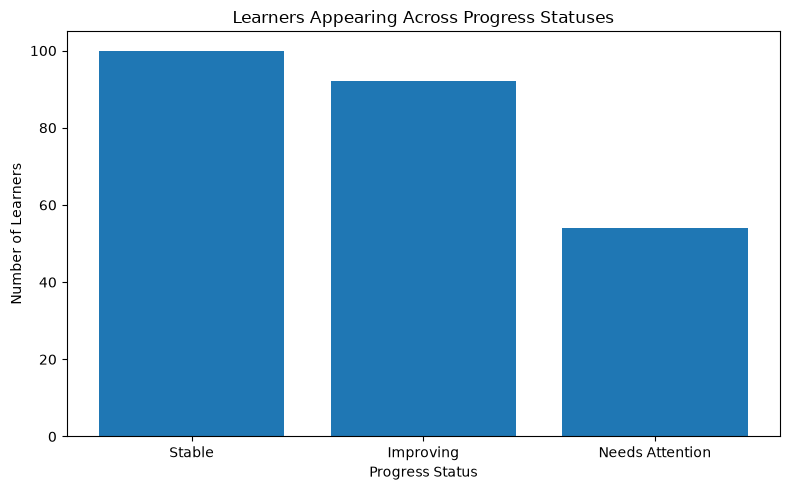

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    progress_status_chart["progress_status"],
    progress_status_chart["learners"]
)

plt.title("Learners Appearing Across Progress Statuses")
plt.xlabel("Progress Status")
plt.ylabel("Number of Learners")

plt.tight_layout()
plt.show()

In [24]:
progress_change_chart = (
    progress
    .groupby("progress_status")["score_change"]
    .mean()
    .reset_index()
    .sort_values(
        "score_change",
        ascending=False
    )
)

progress_change_chart

,progress_status,score_change
0,Improving,8.497143
2,Stable,0.171264
1,Needs Attention,-7.698039


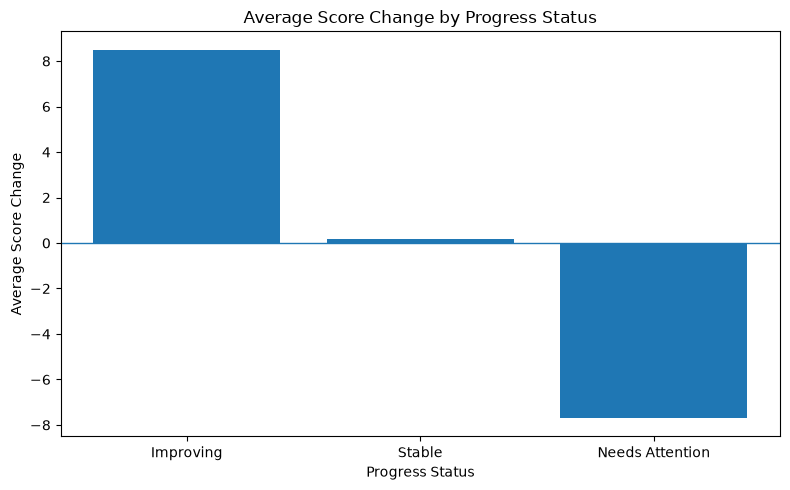

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    progress_change_chart["progress_status"],
    progress_change_chart["score_change"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Average Score Change by Progress Status")
plt.xlabel("Progress Status")
plt.ylabel("Average Score Change")

plt.tight_layout()
plt.show()

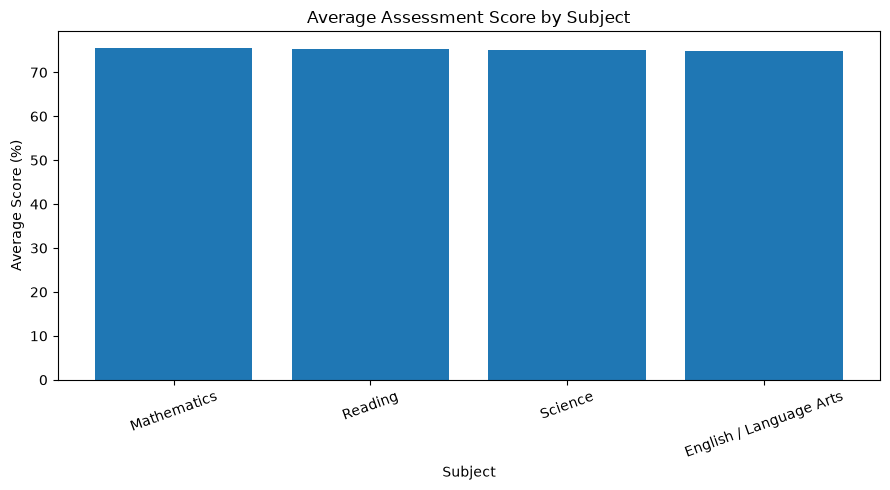

In [26]:
plt.figure(figsize=(9, 5))

plt.bar(
    subject_performance["subject"],
    subject_performance["average_score"]
)

plt.title("Average Assessment Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score (%)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

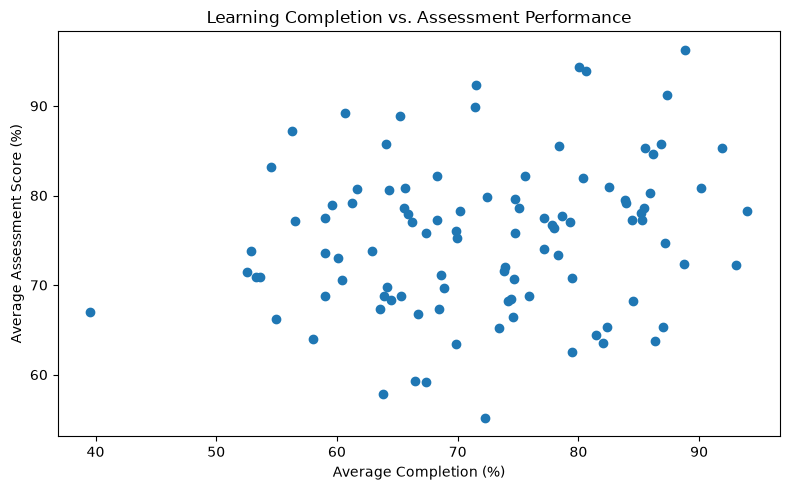

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    engagement_performance["average_completion"],
    engagement_performance["average_score"]
)

plt.title("Learning Completion vs. Assessment Performance")
plt.xlabel("Average Completion (%)")
plt.ylabel("Average Assessment Score (%)")

plt.tight_layout()
plt.show()

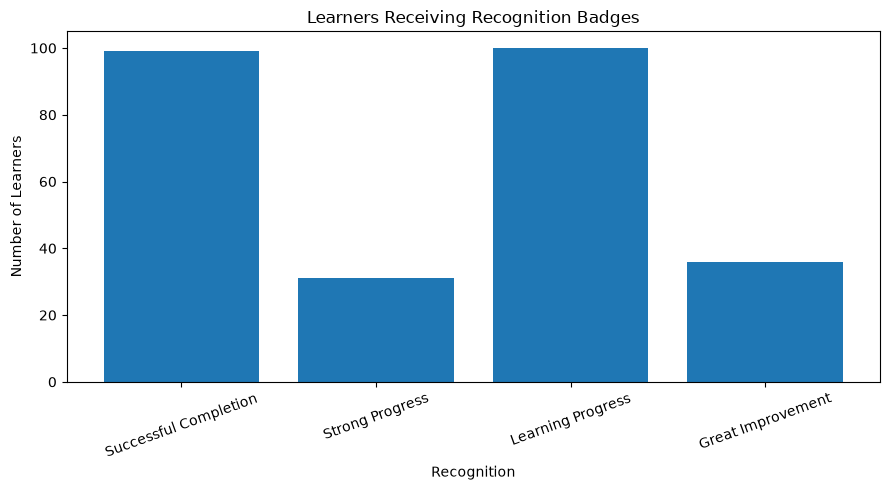

In [28]:
badge_chart = (
    progress
    .groupby("badge_earned")["learner_id"]
    .nunique()
    .reset_index(name="learners")
    .merge(
        progress[
            ["badge_earned", "recognition_tag"]
        ].drop_duplicates(),
        on="badge_earned",
        how="left"
    )
)

plt.figure(figsize=(9, 5))

plt.bar(
    badge_chart["recognition_tag"],
    badge_chart["learners"]
)

plt.title("Learners Receiving Recognition Badges")
plt.xlabel("Recognition")
plt.ylabel("Number of Learners")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

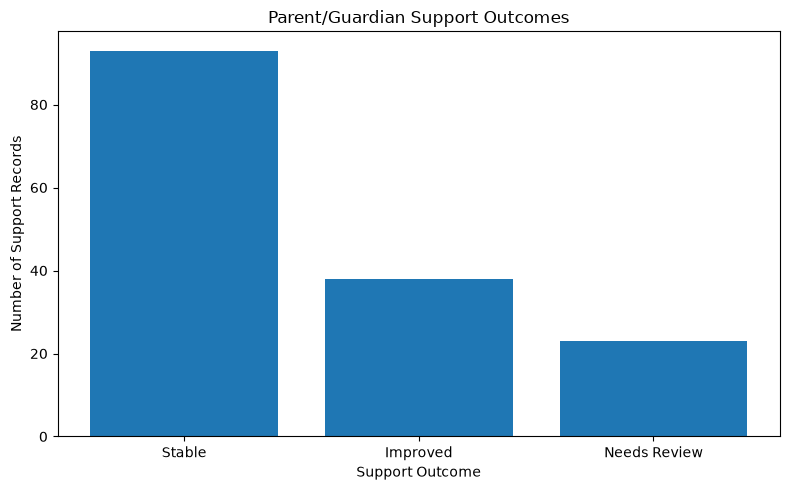

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    support_outcome_summary["support_outcome"],
    support_outcome_summary["support_records"]
)

plt.title("Parent/Guardian Support Outcomes")
plt.xlabel("Support Outcome")
plt.ylabel("Number of Support Records")

plt.tight_layout()
plt.show()

In [30]:
print("=" * 70)
print("EDUVANTA ACADEMY — LEARNING ANALYTICS KEY FINDINGS")
print("=" * 70)

print("\nDATASET")
print("• Synthetic educational dataset")
print("• 100 anonymous K–8 learners")
print("• 12-month learning period: September 2025 – August 2026")
print("• 12 courses across Mathematics, Reading, Science, and English/Language Arts")

print("\nLEARNER PROFILE")
print("• 55 learners classified as Developing")
print("• 36 classified as Proficient")
print("• 6 classified as Beginning")
print("• 3 classified as Advanced")

print("\nSUBJECT PERFORMANCE")
print("• Mathematics had the highest average assessment score: 75.56%")
print("• English / Language Arts had the lowest: 74.97%")
print("• Subject averages were relatively close overall")

print("\nENGAGEMENT & PERFORMANCE")
print("• Completion rate had the strongest association with assessment performance")
print("• Correlation between completion and assessment score: r = 0.202")
print("• The relationship is positive but weak and does not establish causation")

print("\nLEARNER PROGRESS")
print("• Improving records averaged +8.50 score change")
print("• Stable records averaged +0.17 score change")
print("• Needs Attention records averaged -7.70 score change")

print("\nRECOGNITION")
print("• Learning Milestone was the most frequently recorded recognition")
print("• Course Completion, Growth Champion, and Progress Star were also represented")

print("\nPARENT/GUARDIAN SUPPORT")
print("• 154 support records were analyzed")
print("• 38 records were followed by an Improved outcome")
print("• 93 records were Stable")
print("• 23 records were classified as Needs Review")

print("\nIMPORTANT NOTE")
print("• All data is synthetic and created for analytical demonstration.")
print("• Findings describe patterns in the synthetic dataset and do not establish causation.")
print("=" * 70)

EDUVANTA ACADEMY — LEARNING ANALYTICS KEY FINDINGS

DATASET
• Synthetic educational dataset
• 100 anonymous K–8 learners
• 12-month learning period: September 2025 – August 2026
• 12 courses across Mathematics, Reading, Science, and English/Language Arts

LEARNER PROFILE
• 55 learners classified as Developing
• 36 classified as Proficient
• 6 classified as Beginning
• 3 classified as Advanced

SUBJECT PERFORMANCE
• Mathematics had the highest average assessment score: 75.56%
• English / Language Arts had the lowest: 74.97%
• Subject averages were relatively close overall

ENGAGEMENT & PERFORMANCE
• Completion rate had the strongest association with assessment performance
• Correlation between completion and assessment score: r = 0.202
• The relationship is positive but weak and does not establish causation

LEARNER PROGRESS
• Improving records averaged +8.50 score change
• Stable records averaged +0.17 score change
• Needs Attention records averaged -7.70 score change

RECOGNITION
• Le

In [31]:
print("=" * 60)
print("EDUVANTA ACADEMY — FINAL NOTEBOOK INTEGRITY CHECK")
print("=" * 60)

print("\nDataset row counts:")
print(f"Learners: {len(learners):,}")
print(f"Courses: {len(courses):,}")
print(f"Learning activities: {len(learning_activity):,}")
print(f"Assessments: {len(assessments):,}")
print(f"Progress records: {len(progress):,}")
print(f"Parent/guardian support records: {len(parent_support):,}")

print("\nExpected row counts:")
expected = {
    "Learners": 100,
    "Courses": 12,
    "Learning activities": 5594,
    "Assessments": 2245,
    "Progress records": 1200,
    "Parent/guardian support records": 154
}

actual = {
    "Learners": len(learners),
    "Courses": len(courses),
    "Learning activities": len(learning_activity),
    "Assessments": len(assessments),
    "Progress records": len(progress),
    "Parent/guardian support records": len(parent_support)
}

for name in expected:
    status = "PASS" if actual[name] == expected[name] else "CHECK"
    print(f"{name}: {status}")

print("\nKey analysis objects:")
objects = [
    "assessment_summary",
    "subject_performance",
    "engagement_performance",
    "progress_summary",
    "badge_summary",
    "support_summary",
    "support_outcome_summary"
]

for name in objects:
    print(f"{name}: {'OK' if name in globals() else 'MISSING'}")

print("\nFINAL STATUS:")
if actual == expected and all(name in globals() for name in objects):
    print("PASS — Dataset and completed analysis are intact.")
else:
    print("CHECK — Something needs review.")

print("=" * 60)

EDUVANTA ACADEMY — FINAL NOTEBOOK INTEGRITY CHECK

Dataset row counts:
Learners: 100
Courses: 12
Learning activities: 5,594
Assessments: 2,245
Progress records: 1,200
Parent/guardian support records: 154

Expected row counts:
Learners: PASS
Courses: PASS
Learning activities: PASS
Assessments: PASS
Progress records: PASS
Parent/guardian support records: PASS

Key analysis objects:
assessment_summary: OK
subject_performance: OK
engagement_performance: OK
progress_summary: OK
badge_summary: OK
support_summary: OK
support_outcome_summary: OK

FINAL STATUS:
PASS — Dataset and completed analysis are intact.


In [32]:
print(df.columns.tolist())

['support_id', 'learner_id', 'course_id', 'support_date', 'observed_pattern', 'support_area', 'suggested_home_support', 'follow_up_date', 'follow_up_score', 'support_outcome']


In [33]:
print([name for name in globals() if not name.startswith("_")])

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'Path', 'pd', 'np', 'PROJECT_ROOT', 'RAW_DATA_DIR', 'learners', 'courses', 'learning_activity', 'assessments', 'progress', 'parent_support', 'table_summary', 'datasets', 'name', 'df', 'missing_summary', 'column', 'missing_count', 'missing_percentage', 'missing_df', 'duplicate_summary', 'relationship_checks', 'check', 'result', 'date_ranges', 'dates', 'assessment_summary', 'subject_performance', 'learner_engagement', 'learner_performance', 'engagement_performance', 'correlation_results', 'progress_summary', 'badge_summary', 'support_summary', 'support_outcome_summary', 'progress_status_chart', 'plt', 'progress_change_chart', 'badge_chart', 'expected', 'actual', 'status', 'objects']


In [34]:
subject_performance

,subject,assessments,learners,average_score,median_score
1,Mathematics,584,75,75.561644,75.0
2,Reading,570,76,75.425263,75.0
3,Science,474,65,75.062236,75.0
0,English / Language Arts,617,77,74.966937,75.0


In [35]:
learner_engagement

,learner_id,total_activities,average_participation,average_completion,average_session_minutes
0,L001,59,73.093220,72.398305,36.186441
1,L002,62,70.666129,71.470968,36.322581
2,L003,60,86.196667,87.375000,40.116667
3,L004,59,70.540678,70.172881,36.254237
4,L005,44,52.147727,53.586364,29.136364
...,...,...,...,...,...
95,L096,54,73.822222,72.224074,35.462963
96,L097,55,67.825455,69.887273,35.454545
97,L098,51,67.094118,65.309804,34.941176
98,L099,59,65.059322,61.281356,34.440678


In [36]:
learner_engagement.sort_values(
    "average_participation", ascending=False
).head(5)

,learner_id,total_activities,average_participation,average_completion,average_session_minutes
10,L011,50,96.894000,93.086000,42.900000
73,L074,53,96.560377,93.981132,42.603774
35,L036,51,94.019608,91.923529,45.058824
24,L025,52,92.605769,87.165385,41.615385
27,L028,70,92.008571,90.177143,42.042857


In [37]:
learner_engagement.sort_values(
    "average_participation", ascending=True
).head(5)

,learner_id,total_activities,average_participation,average_completion,average_session_minutes
87,L088,60,41.061667,39.581667,27.583333
12,L013,59,50.645763,53.264407,30.084746
26,L027,56,51.850000,52.537500,27.607143
4,L005,44,52.147727,53.586364,29.136364
47,L048,59,53.681356,54.506780,30.576271


In [38]:
progress_summary

,progress_status,learners,records,average_score_change,average_completion
0,Improving,92,315,8.497143,75.924762
2,Stable,100,783,0.171264,56.827714
1,Needs Attention,54,102,-7.698039,62.823529


In [39]:
learner_performance

,learner_id,assessment_count,average_score
0,L001,20,79.855000
1,L002,22,89.877273
2,L003,23,91.186957
3,L004,19,78.242105
4,L005,21,70.857143
...,...,...,...
95,L096,24,55.150000
96,L097,23,76.039130
97,L098,21,68.752381
98,L099,24,79.195833


In [40]:
learner_performance.sort_values(
    "average_score", ascending=False
).head(5)

,learner_id,assessment_count,average_score
84,L085,22,96.272727
52,L053,22,94.395455
78,L079,24,93.854167
59,L060,25,92.364000
2,L003,23,91.186957


In [41]:
learner_performance.sort_values(
    "average_score", ascending=True
).head(5)

,learner_id,assessment_count,average_score
95,L096,24,55.150000
68,L069,23,57.891304
63,L064,21,59.138095
89,L090,22,59.331818
49,L050,23,62.539130


In [42]:
learner_engagement[
    ["average_participation", "average_completion"]
].corr()

,average_participation,average_completion
average_participation,1.000000,0.988151
average_completion,0.988151,1.000000
